In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from uk_charity_local_authority_analysis.council_asset_sales.preprocessing.panel import (
    DEFAULT_OUTPUT_PATH,
)

In [2]:
# Load observed LAD/year receipts from the prepared repository output.
# Values repeat across charity size categories, so deduplicate first.
panel = pd.read_parquet(DEFAULT_OUTPUT_PATH)
receipt_columns = [
    "financial_year",
    "local_authority_code",
    "local_authority",
    "capital_receipts_gbp_millions",
]
filtered_df = (
    panel.loc[panel["receipt_observed"], receipt_columns]
    .drop_duplicates(["financial_year", "local_authority_code"])
    .rename(columns={"capital_receipts_gbp_millions": "value"})
)
if filtered_df["local_authority"].isna().any():
    raise ValueError("Panel contains missing local-authority names")
period_label = (
    f"{filtered_df['financial_year'].min()} - "
    f"{filtered_df['financial_year'].max()}"
)
print(f"Loaded {len(filtered_df):,} observed LAD/year receipts from {DEFAULT_OUTPUT_PATH}")

Loaded 1,776 observed LAD/year receipts from C:\Users\User\codespace\uk-charity-local-authority-analysis\data\council_asset_sales\output\charity_receipts_panel.parquet


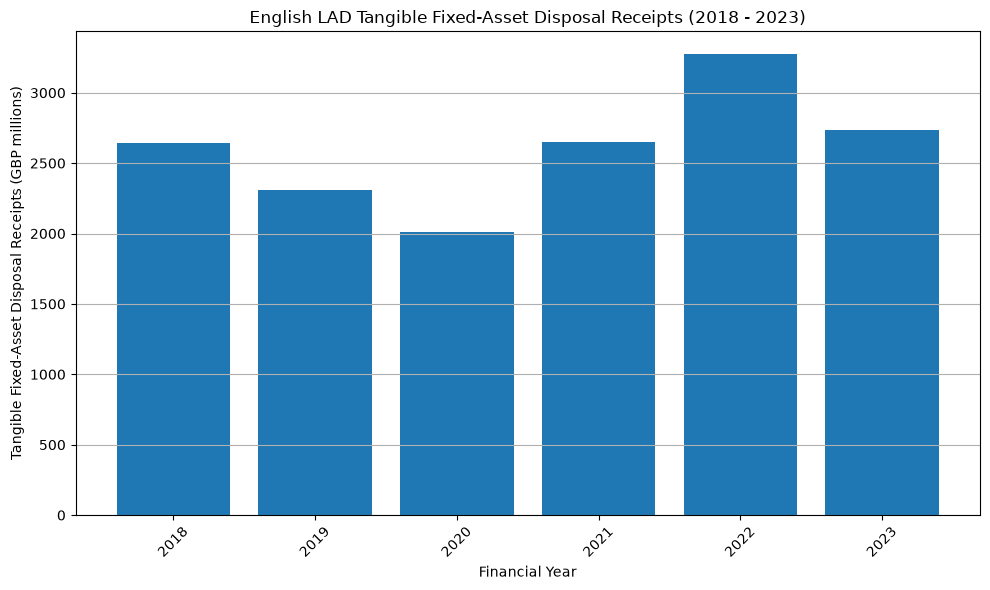

In [3]:
"""
Plot total English LAD tangible fixed-asset disposal receipts by financial year
This shows the total value of tangible fixed-asset disposals by English LADs, grouped by financial year.
"""

# Group by financial year and sum the values
yearly_totals = filtered_df.groupby("financial_year")["value"].sum().reset_index()

# Plot
plt.figure(figsize=(10, 6))
plt.bar(yearly_totals["financial_year"], yearly_totals["value"])

plt.title(
    f"English LAD Tangible Fixed-Asset Disposal Receipts ({period_label})"
)
plt.xlabel("Financial Year")
plt.ylabel("Tangible Fixed-Asset Disposal Receipts (GBP millions)")

# Ensure all years are shown
plt.xticks(ticks=yearly_totals["financial_year"], rotation=45)

plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

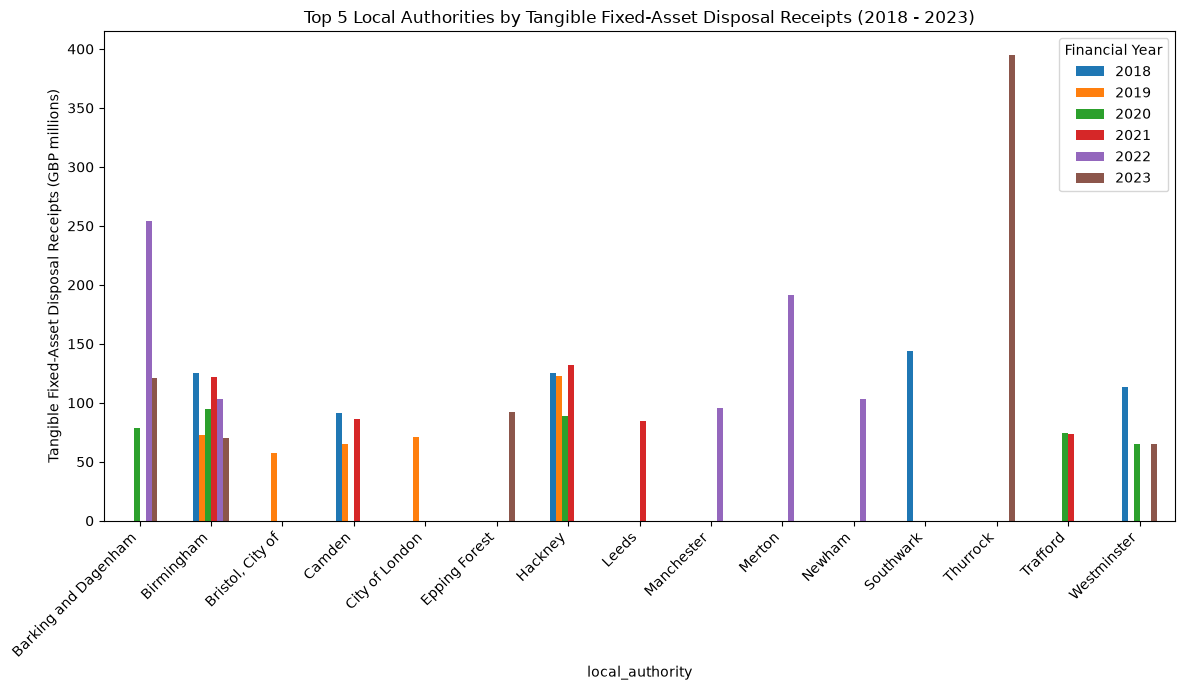

In [4]:
"""
Plot top 5 local authorities by tangible fixed-asset disposal receipts by year
This shows the top 5 local authorities by tangible fixed-asset disposal receipts for all services,
grouped by financial year.
"""

# Group and find top 5 councils per year
top5_per_year = (
    filtered_df.groupby(["financial_year", "local_authority"])["value"]
    .sum()
    .reset_index()
    .sort_values(["financial_year", "value"], ascending=[True, False])
    .groupby("financial_year")
    .head(5)
)

# Pivot the table for plotting
pivot_top5 = top5_per_year.pivot(
    index="local_authority", columns="financial_year", values="value"
)

# Plot
pivot_top5.plot(kind="bar", figsize=(12, 7))

plt.ylabel("Tangible Fixed-Asset Disposal Receipts (GBP millions)")
plt.title(
    f"Top 5 Local Authorities by Tangible Fixed-Asset Disposal Receipts ({period_label})"
)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Financial Year")
plt.tight_layout()
plt.show()

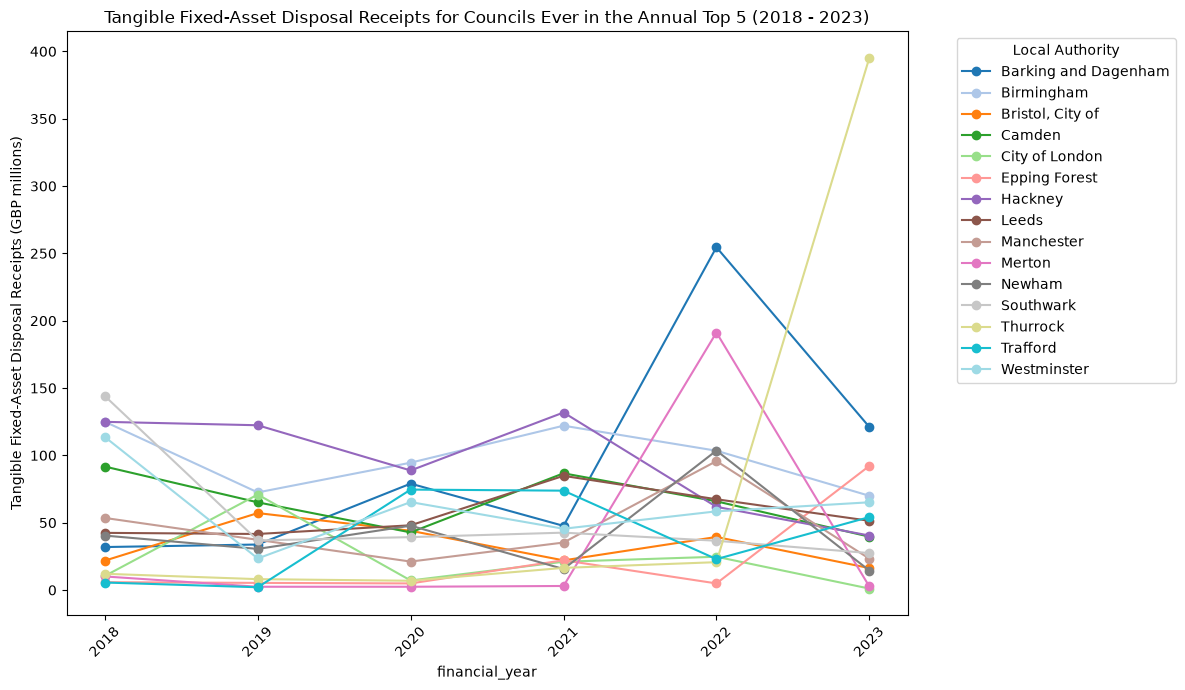

In [5]:
"""
Plot councils that were ever in the top 5 by financial year
This shows councils that were ever in the top 5 by tangible fixed-asset disposal receipts
for any year, plotted as a line graph over the years.
"""

# Get top 5 councils for each year
top5_each_year = (
    filtered_df.groupby(["financial_year", "local_authority"])["value"]
    .sum()
    .reset_index()
    .sort_values(["financial_year", "value"], ascending=[True, False])
    .groupby("financial_year")
    .head(5)
)

# Get unique councils that were ever top 5
top_councils = top5_each_year["local_authority"].unique()

# Filter original data for these councils
df_top_councils = filtered_df[filtered_df["local_authority"].isin(top_councils)]

# Pivot for line plot
pivot_df = (
    df_top_councils.groupby(["financial_year", "local_authority"])["value"]
    .sum()
    .reset_index()
    .pivot(index="financial_year", columns="local_authority", values="value")
)

# Plot
num_lines = pivot_df.shape[1]
colors = plt.colormaps["tab20"].resampled(num_lines).colors

pivot_df.plot(figsize=(12, 7), marker="o", color=colors)  # pass the colour list

plt.ylabel("Tangible Fixed-Asset Disposal Receipts (GBP millions)")
plt.title(
    f"Tangible Fixed-Asset Disposal Receipts for Councils Ever in the Annual Top 5 ({period_label})"
)
plt.xticks(rotation=45)
plt.legend(title="Local Authority", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()